In [1]:
import torch

import numpy as np
import torch.nn as nn

from architecture.pignn.pignn import FlowPIGNN
from utils.visualization import plot_prediction_vs_real
from architecture.pignn.deconv import FCDeConvNet
from graph_experiments import create_data_loaders, get_config

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
# Load the data from a past experiment
case_nr = 1
max_angle = 30
wake_steering = False
use_graph = True
type = "LuT2deg_internal" if wake_steering else "BL"
batch_size = 64
data_folder = f"../../data/Case_0{case_nr}/graphs/{type}/{max_angle}"

config = get_config(case_nr=case_nr, wake_steering=wake_steering, max_angle=max_angle, use_graph=use_graph)
train_loader, val_loader, test_loader = create_data_loaders(data_folder, config.train.batch_size)

In [21]:
print(len(train_loader))

27


In [21]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 906865 parameters without deconv
# 915874 parameters with deconv, conv gives only 1 percent of the params
# 907006 for FCN

In [15]:
# Calculate convolution output sizes
dim_x = 10
dim_y = 50

k = [4, 4, 4]
s = [2, 2, 2]
p = [1, 1, 1]

for i in range(len(k)):
    dim_x = s[i] * (dim_x - 1) + k[i] - 2 * p[i]
    dim_y = s[i] * (dim_y - 1) + k[i] - 2 * p[i]

print(dim_x * dim_y)

32000


In [4]:
# Plot results for fully connected embedder
model = FCDeConvNet(232, 650, 656, 500).to(device)
model.load_state_dict(torch.load("../../results/20240924005510_Case01_False_fcn_deconv/pignn_161.pt"))
model.eval()
criterion = nn.MSELoss()

with torch.no_grad():
    test_losses = []
    for i, batch in enumerate(test_loader):
        x = batch.x.to(device)
        pos = batch.pos.to(device)
        edge_attr = batch.edge_attr.to(device)
        glob = batch.global_feats.to(device)
        batch_size = glob.size(0)

        x_cat = torch.cat((
            x.reshape(batch_size, -1),
            pos.reshape(batch_size, -1),
            edge_attr.reshape(batch_size, -1),
            glob.reshape(batch_size, -1)
        ), dim=-1).float()

        pred = model(x_cat)
        target = batch.y.to(device).reshape(-1, pred.size(1))
        test_loss = criterion(pred, target)
        plot_prediction_vs_real(pred[0, :].reshape(300, 300).cpu(), target[0, :].reshape(300, 300).cpu())
        test_losses.append(test_loss.item())

    print(f"test loss: {np.mean(test_losses)}")

C:\Users\Matth\AppData\Local\Temp\ipykernel_14292\2534070951.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../../results/202409240055

FileNotFoundError: [Errno 2] No such file or directory: '../../results/20240924005510_Case01_False_fcn_deconv/pignn_161.pt'

C:\Users\Matth\AppData\Local\Temp\ipykernel_19632\890895271.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("results/20240930155721_Case

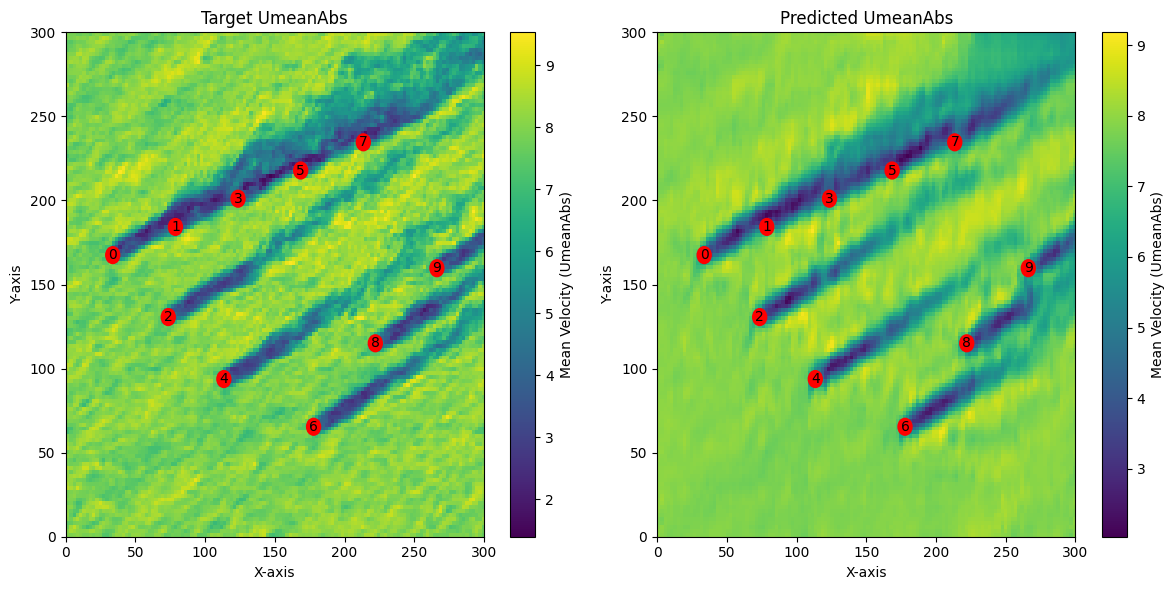

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


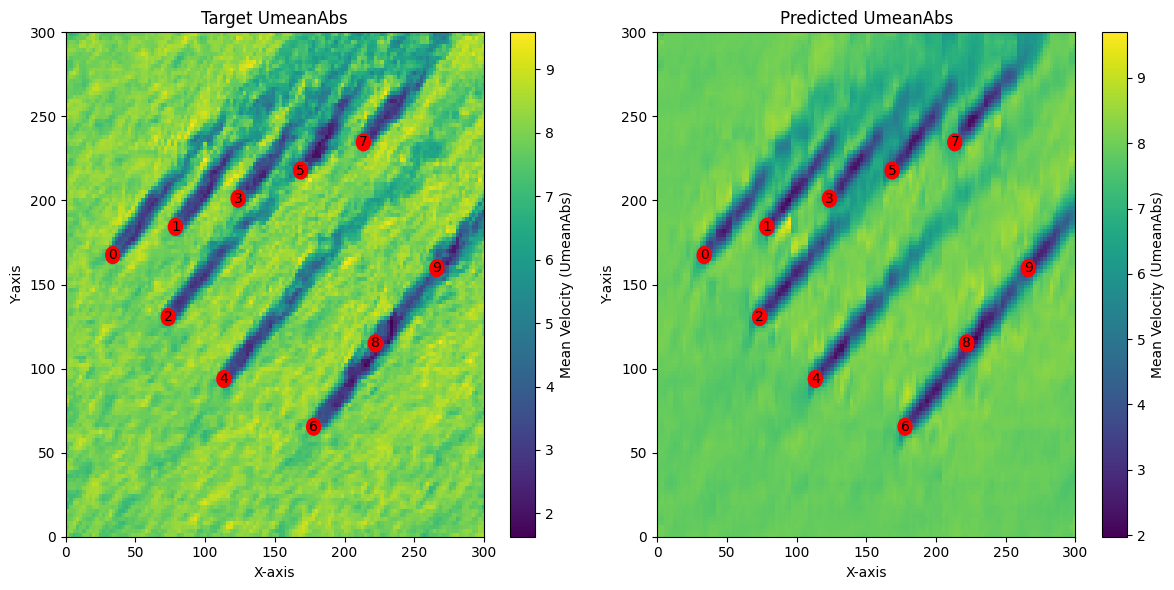

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


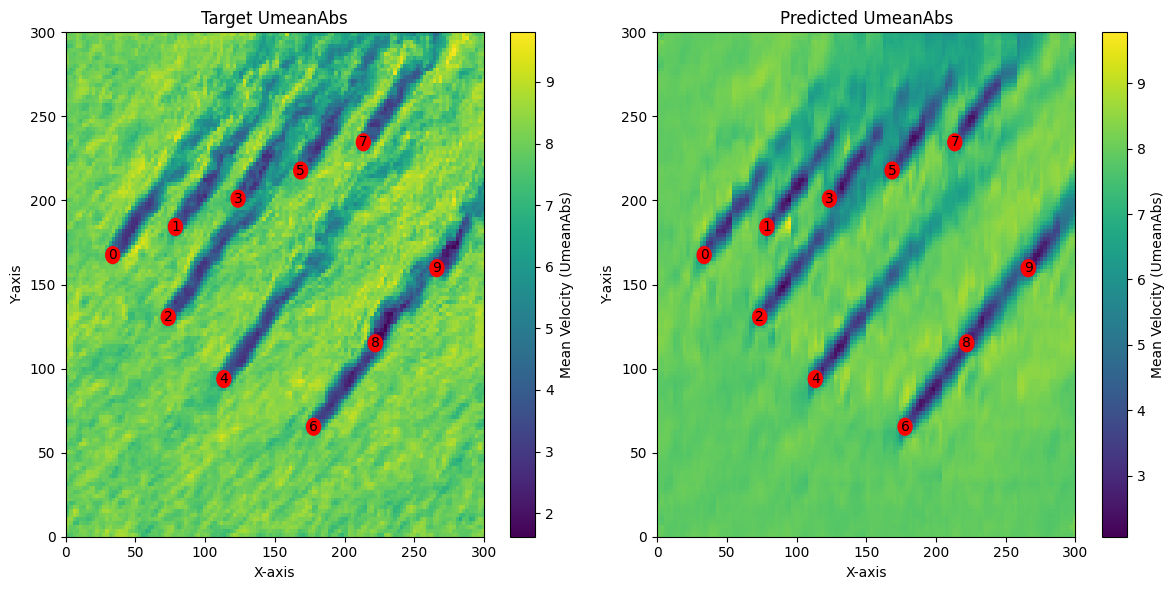

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


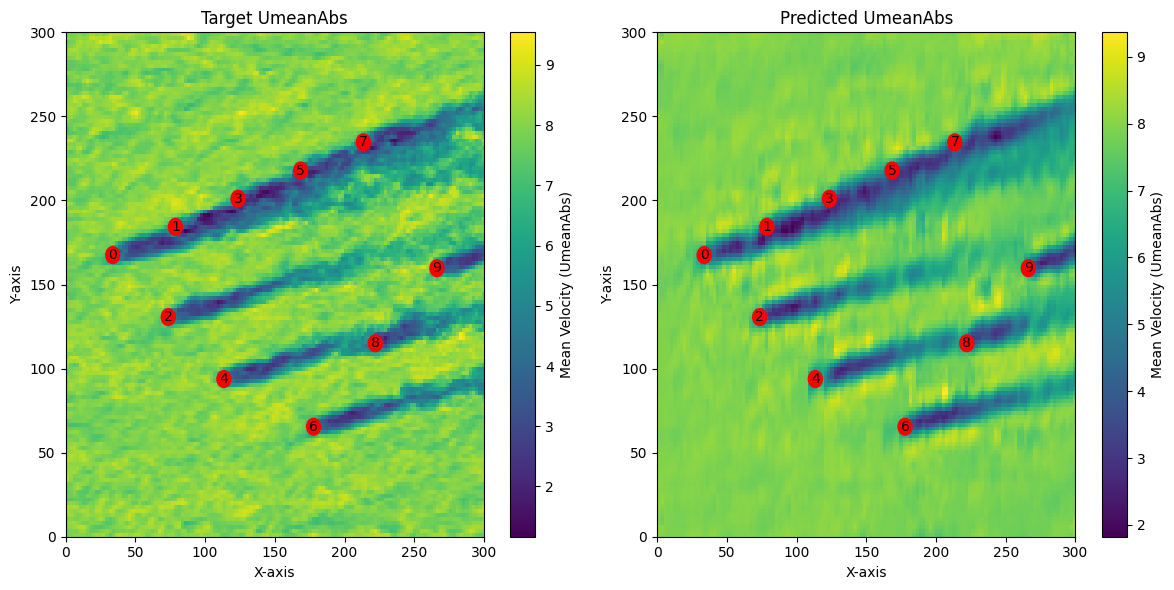

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


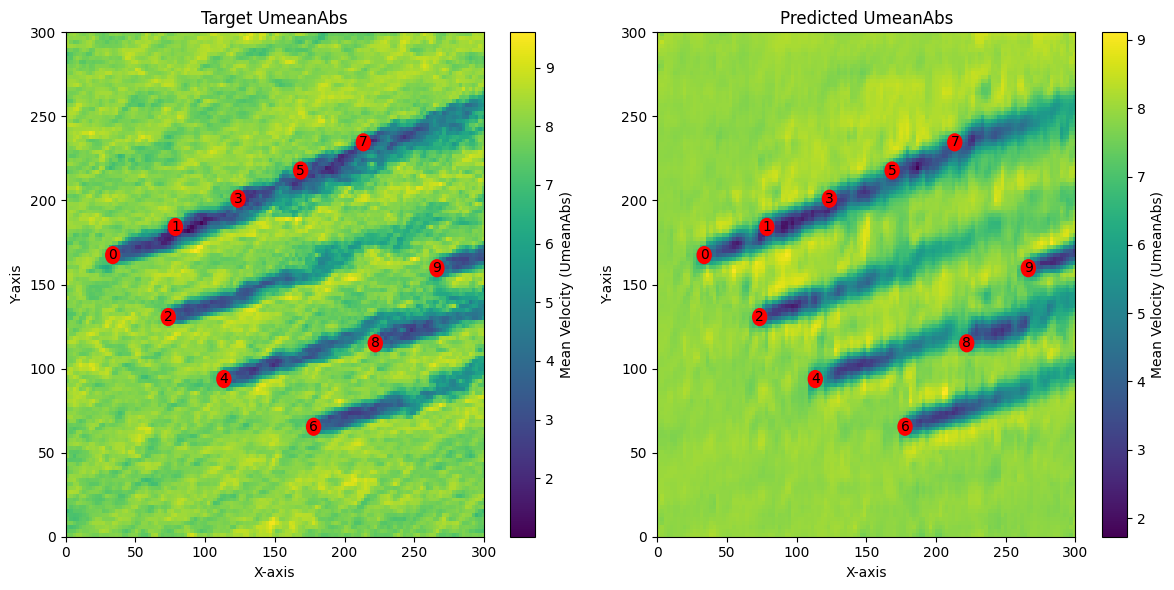

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


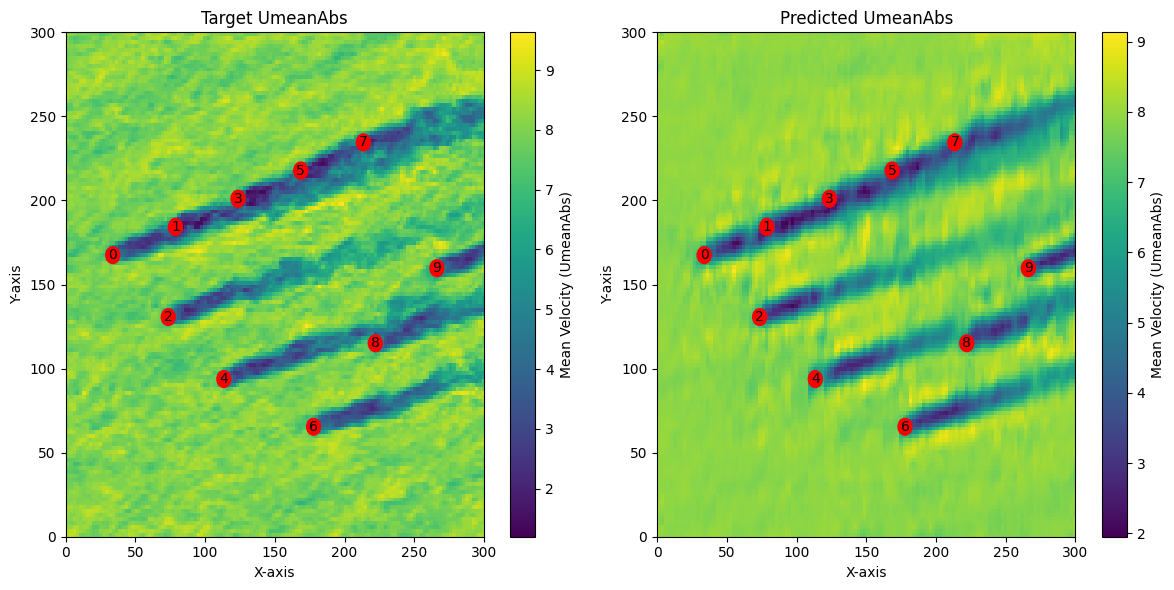

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


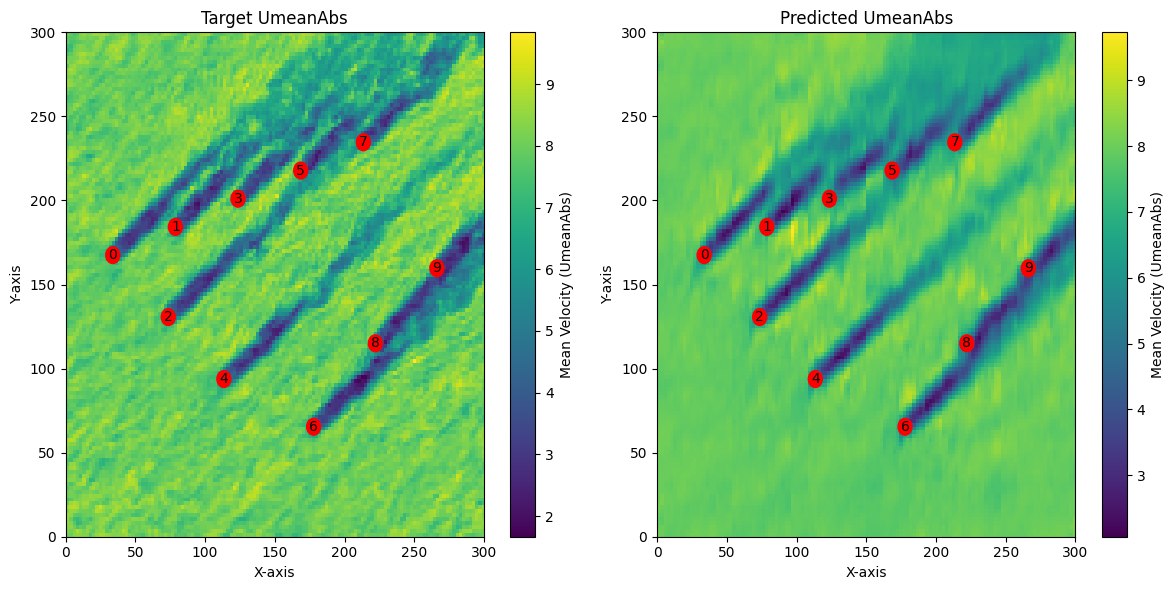

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


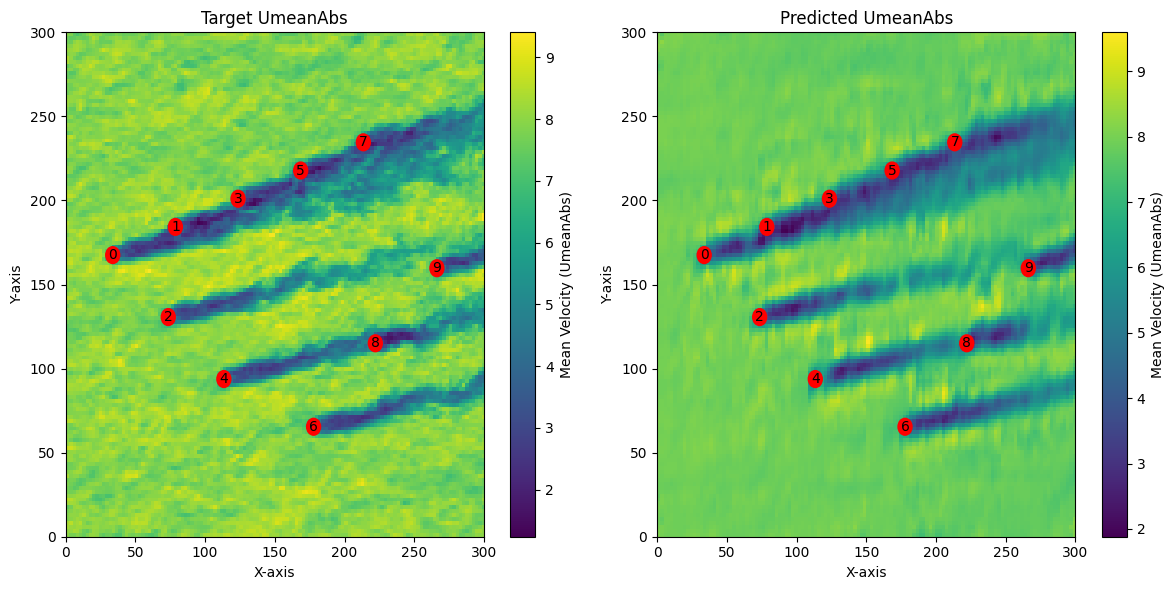

test loss: 0.33705319836735725


In [4]:
# Plot results for PIGNN embedder
model = FlowPIGNN(**config.model).to(device)
model.load_state_dict(torch.load("results/20240930155721_Case01_False_pignn_deconv_30/pignn_101.pt"))
model.eval()
image_size = 128
criterion = nn.MSELoss()

with torch.no_grad():
    test_losses = []
    for i, batch in enumerate(test_loader):
        batch = batch.to(device)
        nf = torch.cat((batch.x.to(device), batch.pos.to(device)), dim=-1).float()
        ef = batch.edge_attr.to(device).float()
        gf = batch.global_feats.to(device).float()
        pred = model(batch, nf, ef, gf)
        target = batch.y.to(device).reshape(-1, pred.size(1))
        test_loss = criterion(pred, target)
        plot_prediction_vs_real(pred[0, :].reshape(image_size, image_size).cpu(), target[0, :].reshape(image_size, image_size).cpu())
        test_losses.append(test_loss.item())

    print(f"test loss: {np.mean(test_losses)}")